# $H_2O$/STO-3G

Reproduction of the numerical figures of "Fermionic entanglement
and quantum correlation measures in molecules" (arXiv 2604.07633) for
$H_2O$/STO-3G

Library code: `h2o_core.py` (electronic structure, spectra, thermal state,
figures) and `h2o_rdm.py` (determinant maps, RDM blocks, measures).

## Model and conventions

* $H_2O$, STO-3G (7 spatial orbitals, $d=14$ spin orbitals), $N=10$,
  $N_\uparrow=N_\downarrow=5$, RHF orbitals labeled 0–6 by orbital energy;
  spin orbitals interleaved (even = $\uparrow$), $R \in [0.4, 4.0]$ Å.
* Both the ground state and the thermal state live in the fixed-$M_S=0$ sector of
  dimension $\binom{7}{5}^2 = 441$. The complete dense spectrum is computed at
  every $R$.
* Thermal state at $\beta = 1000\,E_h^{-1}$, evaluated from the spectral
  decomposition: $q_n = e^{-\beta(E_n-E_0)}$, $p_n = q_n/\sum q$.
* RDM objects: $\rho_\uparrow$ ($21{\times}21$, tr 1),
  $\rho^{(1)}_\uparrow$ ($7{\times}7$, tr 5, $\rho^{(1)}_{ij} =
  \langle c^\dagger_j c_i\rangle$), $\rho^{(2)}_{\uparrow\uparrow}$
  ($21{\times}21$, antisymmetric $i<j$ pair basis, tr 10),
  $\rho^{(2)}_{\uparrow\downarrow}$ ($49{\times}49$, $(i_\uparrow, j_\downarrow)$
  product basis, tr 25).
* Entropies: $S(\rho) = -\sum \lambda\log_2\lambda$
* Negativities (minus the sum of the negative eigenvalues of the
  partial transpose): Eq. (24) total $\mathcal N_{\uparrow\downarrow}$,
  Eq. (26) two-body $\mathcal N^{(2)}_{\uparrow\downarrow}$ on the
  unnormalized $49\times49$ block, Eqs. (28)–(31) same-spin
  $\mathcal N^{(2)}_{\uparrow\uparrow}$. 
* Mutual informations: Eq. (9) $I_{\uparrow\downarrow} = S(\rho_\uparrow) +
  S(\rho_\downarrow) - S(\rho)$, Eq. (17b) $I^{(2)}_{\uparrow\downarrow} =
  N_\downarrow S(\rho^{(1)}_\uparrow) + N_\uparrow S(\rho^{(1)}_\downarrow) -
  S(\rho^{(2)}_{\uparrow\downarrow})$.

In [1]:
import os
for var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS",
            "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(var, "1")

import json
import time

import matplotlib.pyplot as plt

import h2o_core as core

print(f"basis={core.BASIS_NAME}  theta={core.THETA_DEG} deg  "
      f"beta={core.BETA_HARTREE_INVERSE} 1/E_h  "
      f"grid={core.R_GRID[0]}..{core.R_GRID[-1]} A ({len(core.R_GRID)} points)")

basis=sto-3g  theta=104.5 deg  beta=1000.0 1/E_h  grid=0.4..4.0 A (73 points)


In [2]:
t0 = time.time()
SESSION = core.build_session()
POINTS = core.run_scan(session=SESSION)
ARRAYS = core.scan_arrays(POINTS)

R scan: 100%|███████████████████████████████████| 73/73 [04:27<00:00,  3.67s/it]


### Figure 2 - total energies of the lowest-lying states
Electronic plus nuclear-repulsion energies, colored by the verified total spin
$S$ of each root

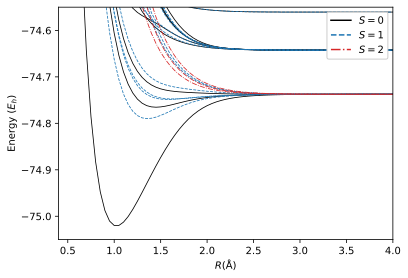

In [3]:
fig = core.plot_figure2(core.compute_figure2_data(ARRAYS))
plt.show()

### Figure 3 - ground-state RDM spectra
Eigenvalues of $\rho_\uparrow$ (identical to those of $\rho_\downarrow$),
$\rho^{(1)}_\uparrow$, $\rho^{(2)}_{\uparrow\downarrow}$ and
$\rho^{(2)}_{\uparrow\uparrow}$

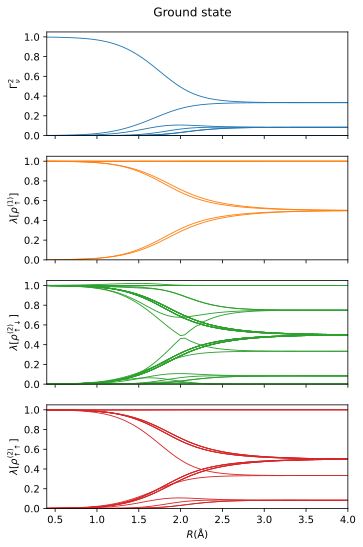

In [4]:
fig = core.plot_figure3(core.compute_figure3_data(ARRAYS))
plt.show()

### Figure 4 - ground-state RDM entropies
Top: plain entropies (bits). Bottom: normalized by the saturation values.

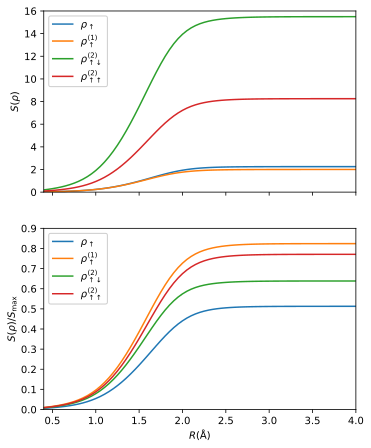

In [5]:
fig = core.plot_figure4(core.compute_figure4_data(ARRAYS))
plt.show()

### Figure 5 - negativities (ground and thermal states)
$\mathcal N_{\uparrow\downarrow}$ (Eq. 24),
$\mathcal N^{(2)}_{\uparrow\downarrow}$ (Eq. 26) and
$\mathcal N^{(2)}_{\uparrow\uparrow}$ (Eq. 31).
The $\mathcal N^{(2)}_{\uparrow\downarrow}$ curve is displayed as $\mathcal N^{(2)}_{\uparrow\downarrow}/2$ 

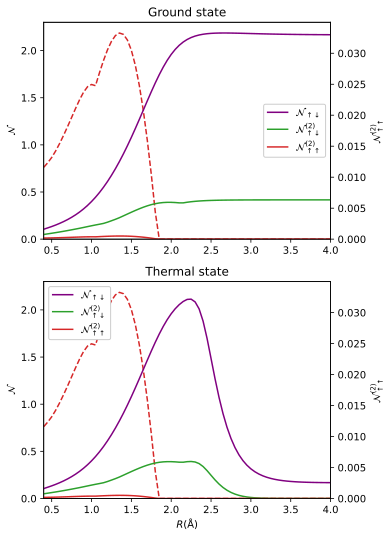

In [6]:
fig = core.plot_figure5(core.compute_figure5_data(ARRAYS))
plt.show()

### Figure 6 - total and two-body up-down mutual informations

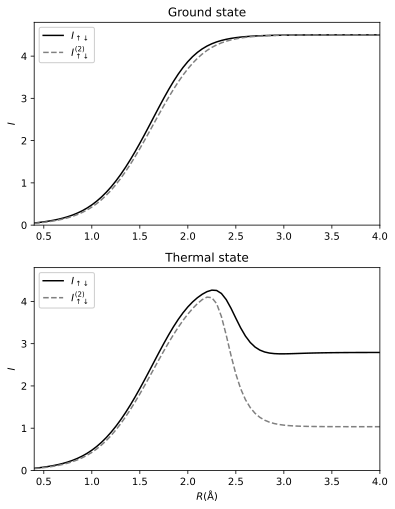

In [7]:
fig = core.plot_figure6(core.compute_figure6_data(ARRAYS))
plt.show()

### Figure 7 - entropies of the thermal weight distributions
$S(\mathbf p)$ for the normalized $p_n$ (approaching $\log_2 12$, dotted line)
and $S(\mathbf q) = -\sum_n q_n\log_2 q_n$ for the unnormalized
$q_n = e^{-\beta(E_n-E_0)}$.

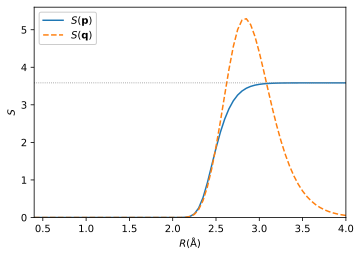

In [8]:
fig = core.plot_figure7(core.compute_figure7_data(ARRAYS))
plt.show()

### Figure 8 - thermal-state RDM spectra
The four RDM objects of Fig. 3 evaluated on $\rho(\beta)$

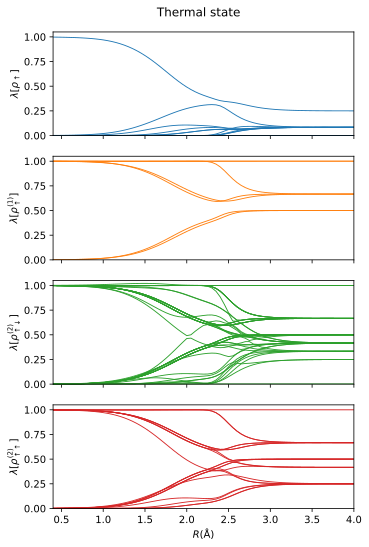

In [9]:
fig = core.plot_figure8(core.compute_figure8_data(ARRAYS))
plt.show()